# HW2 DETR - Colab Version
Ready for Google Colab with Drive + GPU

In [1]:
!pip install -q transformers torchvision

In [2]:
from google.colab import drive
drive.mount('/content/drive')
!unzip "/content/drive/MyDrive/nycu-hw2-data.zip" -d /content/

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
  inflating: /content/nycu-hw2-data/train/8507.png  
  inflating: /content/nycu-hw2-data/train/8508.png  
  inflating: /content/nycu-hw2-data/train/8509.png  
  inflating: /content/nycu-hw2-data/train/851.png  
  inflating: /content/nycu-hw2-data/train/8510.png  
  inflating: /content/nycu-hw2-data/train/8511.png  
  inflating: /content/nycu-hw2-data/train/8512.png  
  inflating: /content/nycu-hw2-data/train/8513.png  
  inflating: /content/nycu-hw2-data/train/8514.png  
  inflating: /content/nycu-hw2-data/train/8515.png  
  inflating: /content/nycu-hw2-data/train/8516.png  
  inflating: /content/nycu-hw2-data/train/8517.png  
  inflating: /content/nycu-hw2-data/train/8518.png  
  inflating: /content/nycu-hw2-data/train/8519.png  
  inflating: /content/nycu-hw2-data/train/852.png  
  inflating: /content/nycu-hw2-data/train/8520.png  
  inflating: /content/nycu-hw2-data/train/8521.png  
  inflating: /content/n

In [3]:
import os

# DATA_DIR should point to the directory where the zip file was unzipped
DATA_DIR = "/content/nycu-hw2-data"

# Define paths for JSON and test data based on the new DATA_DIR
TRAIN_JSON = DATA_DIR + "/train.json"
VALID_JSON = DATA_DIR + "/valid.json"
TEST_DIR = DATA_DIR + "/test"

print(f"DATA_DIR is now set to: {DATA_DIR}")
print(f"TRAIN_JSON is now set to: {TRAIN_JSON}")
print(f"VALID_JSON is now set to: {VALID_JSON}")
print(f"TEST_DIR is now set to: {TEST_DIR}")


DATA_DIR is now set to: /content/nycu-hw2-data
TRAIN_JSON is now set to: /content/nycu-hw2-data/train.json
VALID_JSON is now set to: /content/nycu-hw2-data/valid.json
TEST_DIR is now set to: /content/nycu-hw2-data/test


In [4]:
import torch
from torch.utils.data import DataLoader
from transformers import DetrForObjectDetection, DetrImageProcessor
from PIL import Image
import json, os
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
with open(TRAIN_JSON) as f:
    train_coco = json.load(f)

with open(VALID_JSON) as f:
    valid_coco = json.load(f)

In [6]:
from transformers import DetrImageProcessor

processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50", do_random_flip=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

In [7]:
class CocoDataset(torch.utils.data.Dataset):
    def __init__(self, img_dir, coco):
        self.img_dir = img_dir
        self.coco = coco

        valid_image_ids = set()
        for img_info in coco["images"]:
            path = os.path.join(img_dir, img_info["file_name"])
            if os.path.exists(path):
                valid_image_ids.add(img_info["id"])

        filtered_annotations = []
        for ann in coco["annotations"]:
            if ann["image_id"] not in valid_image_ids:
                continue
            x, y, w, h = ann["bbox"]
            if (w > 1 and h > 1 and x >= 0 and y >= 0 and
                    all(map(lambda v: not (v != v) and abs(v) != float('inf'), [x, y, w, h]))):
                filtered_annotations.append(ann)

        self.img_to_anns = {}
        for ann in filtered_annotations:
            self.img_to_anns.setdefault(ann["image_id"], []).append(ann)

        # ✅ NOUVEAU : on garde uniquement les images qui ont AU MOINS 1 annotation valide
        self.images = [
            img for img in coco["images"]
            if img["id"] in valid_image_ids and img["id"] in self.img_to_anns
        ]

        print(f"Dataset: {len(self.images)} images with valid annotations")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        path = os.path.join(self.img_dir, img_info["file_name"])
        image = Image.open(path).convert("RGB")
        img_w, img_h = image.size

        anns = self.img_to_anns.get(img_info["id"], [])

        safe_anns = []
        for ann in anns:
            x, y, w, h = ann["bbox"]
            x = max(0.0, min(x, img_w - 1))
            y = max(0.0, min(y, img_h - 1))
            w = min(w, img_w - x)
            h = min(h, img_h - y)
            if w > 1 and h > 1:
                new_ann = dict(ann)
                new_ann["bbox"] = [x, y, w, h]
                safe_anns.append(new_ann)

        # ✅ NOUVEAU : si toutes les anns sont devenues invalides après clipping, on skip
        if not safe_anns:
            return self.__getitem__((idx + 1) % len(self.images))

        target = {"image_id": img_info["id"], "annotations": safe_anns}
        return image, target

In [8]:
def make_collate_fn(processor):
    def collate_fn_with_processor(batch):
        images = [item[0] for item in batch]
        targets = [item[1] for item in batch]

        # ✅ NOUVEAU : on filtre les items dont les boîtes seraient vides après tout
        valid_pairs = [
            (img, tgt) for img, tgt in zip(images, targets)
            if tgt["annotations"]
        ]
        if not valid_pairs:
            return None  # le training loop va skipper ce batch
        images, targets = zip(*valid_pairs)

        try:
            encoding = processor(images=list(images), annotations=list(targets), return_tensors="pt")
        except Exception as e:
            print(f"  [collate_fn] processor error: {e} — batch skipped")
            return None

        safe_labels = []
        for label in encoding["labels"]:
            safe_label = {}
            for k, v in label.items():
                if v.is_floating_point():
                    # ✅ Forcer float32 pour éviter le float16 avant autocast
                    v = v.float()
                    v = torch.nan_to_num(v, nan=0.0, posinf=1.0, neginf=0.0)
                safe_label[k] = v
            safe_labels.append(safe_label)

        return {
            "pixel_values": encoding["pixel_values"],
            "pixel_mask": encoding["pixel_mask"],
            "labels": safe_labels,
        }

    return collate_fn_with_processor

In [9]:
train_dataset = CocoDataset(DATA_DIR + "/train", train_coco)
valid_dataset = CocoDataset(DATA_DIR + "/valid", valid_coco)

# Pass the processor to the collate_fn factory
train_collate_fn = make_collate_fn(processor)
valid_collate_fn = make_collate_fn(processor)

# Increase batch size and add pin_memory, persistent_workers for better performance
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=train_collate_fn, num_workers=2, pin_memory=True, persistent_workers=True)
valid_loader = DataLoader(valid_dataset, batch_size=16, collate_fn=valid_collate_fn, num_workers=2, pin_memory=True, persistent_workers=True)

Dataset: 30059 images with valid annotations
Dataset: 3339 images with valid annotations


In [10]:
from transformers import DetrConfig, DetrForObjectDetection

# Instantiate a default DETR configuration with the correct number of labels
NUM_DATASET_CLASSES = len(train_coco['categories'])

# Load the base configuration from a pre-trained model to ensure all architectural details are correct
config = DetrConfig.from_pretrained("facebook/detr-resnet-50")
# Set the number of labels for our specific dataset
config.num_labels = NUM_DATASET_CLASSES + 1

model = DetrForObjectDetection(config) # Model is instantiated with this config but without loading pre-trained weights
model.to(device)

# Separate LR for backbone vs transformer heads (standard DETR practice)
param_dicts = [
    {"params": [p for n, p in model.named_parameters() if "backbone" not in n and p.requires_grad]},
    {"params": [p for n, p in model.named_parameters() if "backbone" in n and p.requires_grad], "lr": 1e-5},
]
optimizer = torch.optim.AdamW(param_dicts, lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

In [ ]:
from tqdm.notebook import tqdm  # ✅ version notebook
import torch.amp as amp

train_losses = []
valid_losses = []
scaler = amp.GradScaler('cuda')

NUM_EPOCHS = 25
best_valid_loss = float('inf')
best_epoch = -1

for epoch in range(NUM_EPOCHS):
    model.train()
    total_train_loss = 0
    train_valid_steps = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} (Training)"):
        # ✅ NOUVEAU : skip les batchs None retournés par collate_fn
        if batch is None:
            continue

        pixel_values = batch["pixel_values"].to(device)
        pixel_mask = batch["pixel_mask"].to(device)
        labels = [{k: v.to(device) for k, v in t.items()} for t in batch["labels"]]

        # ✅ NOUVEAU : vérification explicite des boîtes avant la forward pass
        skip = False
        for t in labels:
            if not torch.isfinite(t["boxes"]).all():
                print("  Warning: NaN boxes détectées après collate, batch skippé")
                skip = True
                break
        if skip:
            continue

        optimizer.zero_grad()

        with amp.autocast('cuda'):
            outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=labels)
            loss = outputs.loss

        if not torch.isfinite(loss):
            print(f"  Warning: non-finite loss ({loss.item()}), skipping batch")
            optimizer.zero_grad()
            continue

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
        scaler.step(optimizer)
        scaler.update()

        total_train_loss += loss.item()
        train_valid_steps += 1

    if train_valid_steps == 0:
        print(f"  ⚠️ Epoch {epoch+1} : aucun batch valide !")
        train_losses.append(float('nan'))
    else:
        avg_train_loss = total_train_loss / train_valid_steps
        train_losses.append(avg_train_loss)
        scheduler.step()  # ✅ step seulement si on a vraiment entraîné

    # --- Validation ---
    model.eval()
    total_valid_loss = 0
    valid_steps_count = 0

    with torch.no_grad():
        for batch in tqdm(valid_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} (Validation)"):
            if batch is None:
                continue

            pixel_values = batch["pixel_values"].to(device)
            pixel_mask = batch["pixel_mask"].to(device)
            labels = [{k: v.to(device) for k, v in t.items()} for t in batch["labels"]]

            skip = False
            for t in labels:
                if not torch.isfinite(t["boxes"]).all():
                    skip = True
                    break
            if skip:
                continue

            with amp.autocast('cuda'):
                outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=labels)
                loss = outputs.loss

            if not torch.isfinite(loss):
                continue

            total_valid_loss += loss.item()
            valid_steps_count += 1

    avg_valid_loss = total_valid_loss / max(valid_steps_count, 1)
    valid_losses.append(avg_valid_loss)

    current_lr = scheduler.get_last_lr()[0]
    avg_tl = train_losses[-1]
    print(f"Epoch {epoch+1} | Train Loss: {avg_tl:.4f} | Valid Loss: {avg_valid_loss:.4f} | LR: {current_lr:.1e}")

    if avg_valid_loss < best_valid_loss:
        best_valid_loss = avg_valid_loss
        best_epoch = epoch + 1
        torch.save({
            'epoch': best_epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_valid_loss': best_valid_loss,
        }, "/content/drive/MyDrive/best_detr_model.pth")
        print(f"  --> Best model saved at epoch {best_epoch} (valid loss: {best_valid_loss:.4f})")

Epoch 1/25 (Training):   0%|          | 0/1879 [00:00<?, ?it/s]

Epoch 1/25 (Validation):   0%|          | 0/209 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 2.4805 | Valid Loss: 4.0856 | LR: 1.0e-04
  --> Best model saved at epoch 1 (valid loss: 4.0856)


Epoch 2/25 (Training):   0%|          | 0/1879 [00:00<?, ?it/s]

Epoch 2/25 (Validation):   0%|          | 0/209 [00:00<?, ?it/s]

...

Epoch 24/25 (Validation):   0%|          | 0/209 [00:00<?, ?it/s]

Epoch 24 | Train Loss: 2.0748 | Valid Loss: 4.1746 | LR: 1.0e-06


Epoch 25/25 (Training):   0%|          | 0/1879 [00:00<?, ?it/s]

Epoch 25/25 (Validation):   0%|          | 0/209 [00:00<?, ?it/s]

Epoch 25 | Train Loss: 2.0753 | Valid Loss: 4.1847 | LR: 1.0e-06


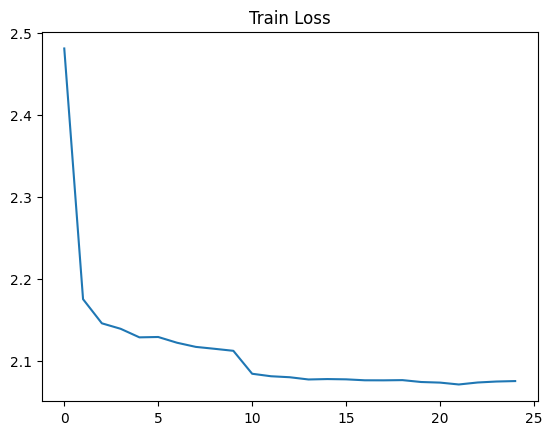

In [ ]:
plt.plot(train_losses)
plt.title("Train Loss")
plt.show()

In [ ]:
import torch

# This cell will now save the final state of the model after all epochs.
# The best model based on validation loss is saved during the training loop in the previous cell.
torch.save(model.state_dict(), "/content/drive/MyDrive/final_detr_model.pth")
print("Final model state saved to /content/drive/MyDrive/final_detr_model.pth")

Final model state saved to /content/drive/MyDrive/final_detr_model.pth


In [11]:
import os, json, torch
from PIL import Image
from tqdm import tqdm
from transformers import DetrForObjectDetection, DetrImageProcessor, DetrConfig

BEST_MODEL_PATH = "/content/drive/MyDrive/best_detr_model.pth"
TEST_DIR        = DATA_DIR + "/test"
OUTPUT_JSON     = "/content/drive/MyDrive/pred.json"
SCORE_THRESHOLD = 0.01

NUM_DATASET_CLASSES = len(train_coco['categories'])

# ✅ Reconstruire le config avec le bon nombre de classes
config_infer = DetrConfig.from_pretrained("facebook/detr-resnet-50")
config_infer.num_labels = NUM_DATASET_CLASSES + 1

model_infer = DetrForObjectDetection(config_infer)

# ✅ Charger le checkpoint complet (dict) et extraire seulement model_state_dict
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    state_dict = checkpoint["model_state_dict"]
    print(f"Checkpoint chargé — epoch {checkpoint.get('epoch', '?')}, valid loss: {checkpoint.get('best_valid_loss', '?'):.4f}")
else:
    # Ancien format : state_dict brut
    state_dict = checkpoint
    print("Checkpoint brut chargé")

model_infer.load_state_dict(state_dict, strict=True)
model_infer.to(device)
model_infer.eval()

processor_infer = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")

# Collect test images
test_images = sorted([
    f for f in os.listdir(TEST_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

predictions = []

with torch.no_grad():
    for fname in tqdm(test_images, desc="Inference"):
        stem = os.path.splitext(fname)[0]
        image_id = int(stem) if stem.isdigit() else stem

        image = Image.open(os.path.join(TEST_DIR, fname)).convert("RGB")
        orig_w, orig_h = image.size

        inputs = processor_infer(images=image, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}

        outputs = model_infer(**inputs)

        target_sizes = torch.tensor([[orig_h, orig_w]], device=device)
        results = processor_infer.post_process_object_detection(
            outputs,
            threshold=SCORE_THRESHOLD,
            target_sizes=target_sizes
        )[0]

        scores = results["scores"].cpu().tolist()
        labels = results["labels"].cpu().tolist()
        boxes  = results["boxes"].cpu().tolist()

        for score, label, box in zip(scores, labels, boxes):
            x0, y0, x1, y1 = box
            w = x1 - x0
            h = y1 - y0
            predictions.append({
                "image_id":    image_id,
                "bbox":        [x0, y0, w, h],
                "score":       score,
                "category_id": label
            })

with open(OUTPUT_JSON, "w") as f:
    json.dump(predictions, f)

print(f"Done — {len(predictions)} predictions saved to {OUTPUT_JSON}")

Checkpoint chargé — epoch 1, valid loss: 4.0856


Inference: 100%|██████████| 13068/13068 [15:26<00:00, 14.11it/s]


Done — 0 predictions saved to /content/drive/MyDrive/pred.json
